## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("TensorFlow", tf.__version__, "| GPU:", gpus)


TensorFlow 2.10.1 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.10.1


## 2. Loading and explore the dataset

Categories: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


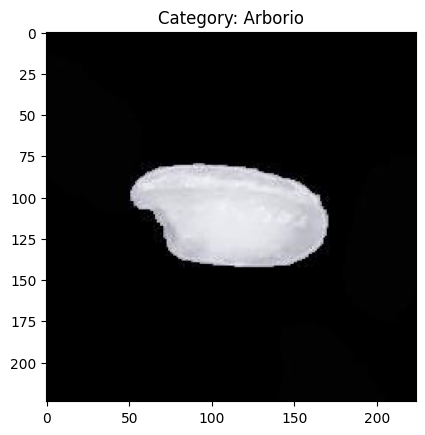

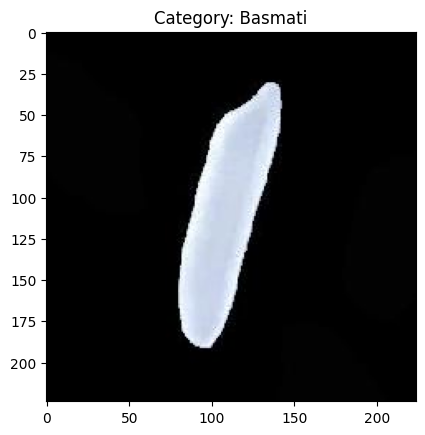

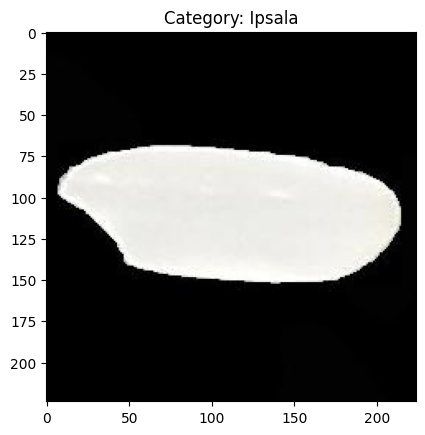

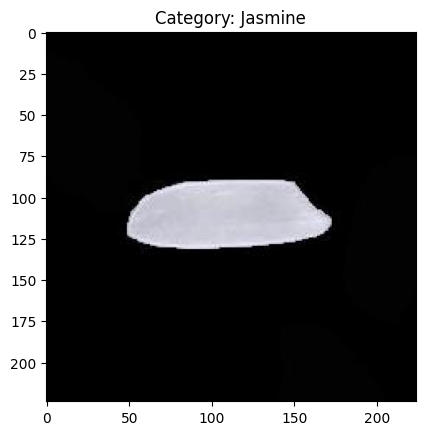

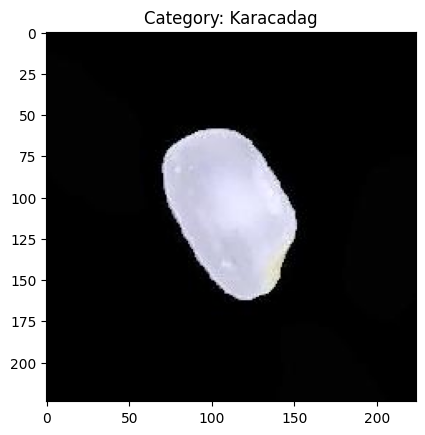

In [5]:
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Define the dataset path
dataset_path = r"D:\Rice_DL_Project\Rice_Classification\data\raw\Rice_Image_Dataset"  

# Explore the dataset
categories = [category for category in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, category))]
print("Categories:", categories)

# Visualize some sample images from each category
for category in categories:
    category_path = os.path.join(dataset_path, category)
    sample_image = os.listdir(category_path)[0]  # Pick one image from each category
    img = image.load_img(os.path.join(category_path, sample_image), target_size=(224, 224))
    plt.imshow(img)
    plt.title(f"Category: {category}")
    plt.show()

## 3. Data Preprocessing

In [6]:
train_datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)
# Flow from directory for training images
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical',  # Multiclass classification
    subset='training'  
)
# Flow from directory for validation images
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical',
    subset='validation' 
)

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.


## 4. CNN model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Initialize the CNN model
model = Sequential()

# Input layer (added explicitly)
model.add(Input(shape=(224, 224, 3)))

# First convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Second convolutional layer
model.add(Conv2D(64, (3, 3), activation='relu'))  
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Third convolutional layer
model.add(Conv2D(128, (3, 3), activation='relu')) 
model.add(MaxPooling2D(pool_size=(2, 2)))  

# Flatten the 2D feature maps into 1D
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Add a Dropout layer to prevent overfitting
model.add(Dropout(0.5))

# Output layer (5 classes for classification)
model.add(Dense(5, activation='softmax'))

## 5. Compiling the CNN Model

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

## 6. Model Training

In [9]:
batch_size=32
history = model.fit(
    train_generator,  # Training data
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=10,  # Number of epochs
    validation_data=validation_generator,  # Validation data
    validation_steps=validation_generator.samples // batch_size  # Number of validation steps
)

Epoch 1/10
1875/1875 [==============================] - 669s 355ms/step - loss: 0.1590 - accuracy: 0.9463 - val_loss: 0.0686 - val_accuracy: 0.9739
Epoch 2/10
1875/1875 [==============================] - 639s 341ms/step - loss: 0.0643 - accuracy: 0.9797 - val_loss: 0.0161 - val_accuracy: 0.9947
Epoch 3/10
1875/1875 [==============================] - 570s 304ms/step - loss: 0.0366 - accuracy: 0.9884 - val_loss: 0.0175 - val_accuracy: 0.9945
Epoch 4/10
1875/1875 [==============================] - 119s 63ms/step - loss: 0.0265 - accuracy: 0.9917 - val_loss: 0.0121 - val_accuracy: 0.9962
Epoch 5/10
1875/1875 [==============================] - 122s 65ms/step - loss: 0.0247 - accuracy: 0.9924 - val_loss: 0.0086 - val_accuracy: 0.9975
Epoch 6/10
1875/1875 [==============================] - 131s 70ms/step - loss: 0.0204 - accuracy: 0.9933 - val_loss: 0.0090 - val_accuracy: 0.9975
Epoch 7/10
1875/1875 [==============================] - 134s 71ms/step - loss: 0.0159 - accuracy: 0.9954 - val_loss

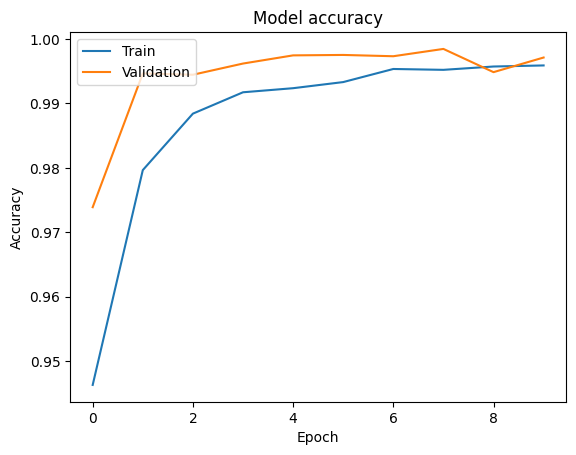

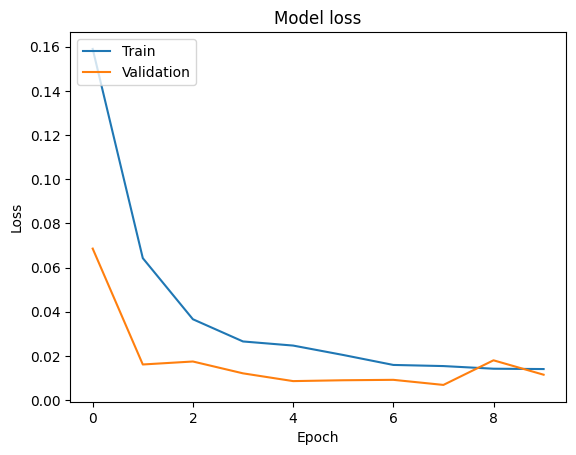

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## 7. Model Evaluation

In [11]:
test_loss, test_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

468/468 [==============================] - 13s 27ms/step - loss: 0.0115 - accuracy: 0.9971
Test Accuracy: 99.71%


## 8. Model Prediction

1/1 [==============================] - 0s 169ms/step


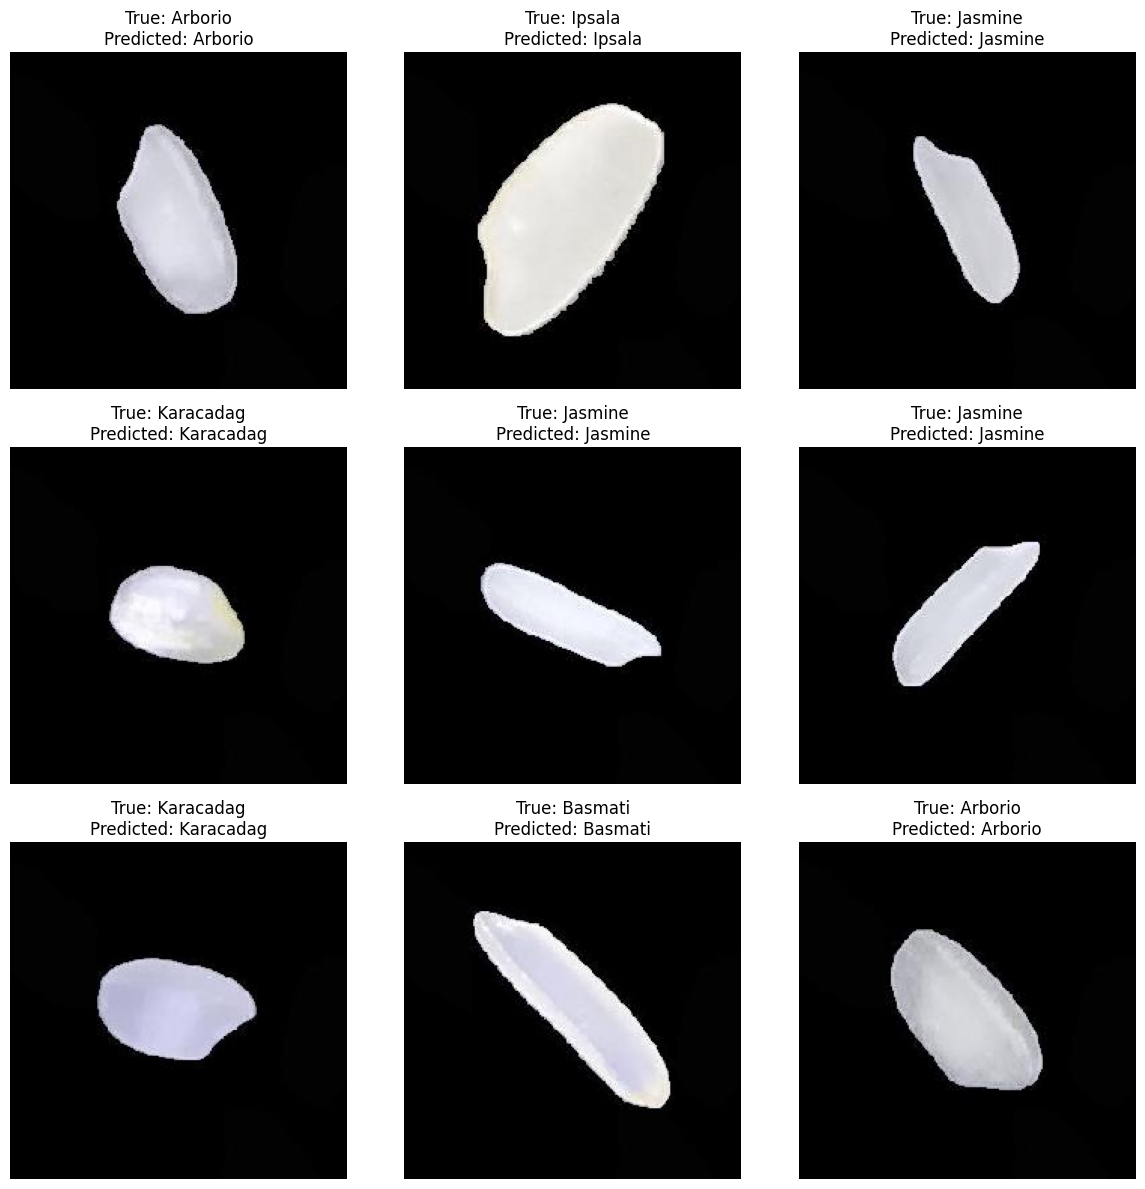

In [12]:
X_test, y_test = validation_generator.next() 
predictions = model.predict(X_test)

def plot_predictions(X_test, y_test, predictions, class_indices):
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test[i])
        true_label = np.argmax(y_test[i])
        predicted_label = np.argmax(predictions[i])
        true_class = list(class_indices.keys())[list(class_indices.values()).index(true_label)]
        predicted_class = list(class_indices.keys())[list(class_indices.values()).index(predicted_label)]
        plt.title(f"True: {true_class}\nPredicted: {predicted_class}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_predictions(X_test, y_test, predictions, validation_generator.class_indices)